# 34b - Within-Subtype MIA Evaluation (TCGA-BRCA)

Re-evaluate all unlearning methods using within-subtype matched negatives
(unseen Basal patients only) to separate memorization from biology.

With cross-subtype matching (NB33), baseline AUC was 0.821 and retrain was 0.860.
This notebook tests whether that signal survives when the biology confound is controlled.

In [1]:
import sys
sys.path.insert(0, '../src')

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
import json
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

from utils import set_global_seed, GLOBAL_SEED, DEVICE
from vae import VAE
from attacker import MLPAttacker, extract_vae_features, build_attack_features
from attacker_eval import matched_negative_evaluation

set_global_seed(GLOBAL_SEED)
plt.style.use('seaborn-v0_8-whitegrid')

DATA_DIR = Path('../data/tcga_brca')
BASELINE_DIR = Path('../outputs/tcga_brca/baseline')
OUTPUT_DIR = Path('../outputs/tcga_brca/within_subtype_eval')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

## Setup

In [2]:
adata = sc.read_h5ad(DATA_DIR / 'tcga_brca_processed.h5ad')
subtypes = adata.obs['subtype'].values

with open('../outputs/tcga_brca/split_structured.json') as f:
    structured_split = json.load(f)

forget_structured = structured_split['forget_indices']
retain_indices = structured_split['retain_indices']
unseen_indices = structured_split['unseen_indices']
unseen_basal = [int(i) for i in unseen_indices if subtypes[i] == 'Basal']

baseline_ckpt = torch.load(BASELINE_DIR / 'best_model.pt', map_location=DEVICE)
config = baseline_ckpt['config']
model_config = {k: v for k, v in config.items()
                if k in ['input_dim', 'latent_dim', 'hidden_dims', 'likelihood', 'dropout', 'use_layer_norm']}

def load_model(path):
    model = VAE(**model_config).to(DEVICE)
    ckpt = torch.load(path, map_location=DEVICE)
    model.load_state_dict(ckpt['model_state_dict'])
    model.eval()
    return model

def extract_features(vae_model, indices):
    X = adata.X[indices]
    if hasattr(X, 'toarray'):
        X = X.toarray()
    x = torch.FloatTensor(X).to(DEVICE)
    lib = x.sum(dim=1, keepdim=True)
    vae_feats = extract_vae_features(vae_model, x, lib, DEVICE, requires_grad=False)
    return build_attack_features(vae_feats, variant='v1')

def eval_within_subtype(vae_model, forget_idx):
    vae_model.eval()
    forget_feats = extract_features(vae_model, forget_idx)
    matched_feats = extract_features(vae_model, unseen_basal)
    input_dim = forget_feats.shape[1]
    attacker = MLPAttacker(input_dim, [256, 256], dropout=0.3, use_spectral_norm=True).to(DEVICE)
    att_opt = optim.Adam(attacker.parameters(), lr=1e-3, weight_decay=1e-4)
    X_train = torch.cat([forget_feats, matched_feats]).to(DEVICE)
    y_train = torch.cat([torch.ones(len(forget_feats)),
                         torch.zeros(len(matched_feats))]).unsqueeze(1).to(DEVICE)
    for _ in range(100):
        attacker.train()
        att_opt.zero_grad()
        loss = nn.functional.binary_cross_entropy_with_logits(attacker(X_train), y_train)
        loss.backward()
        att_opt.step()
    attacker.eval()
    metrics = matched_negative_evaluation(attacker, forget_feats, matched_feats, device=DEVICE)
    auc = metrics['auc']
    return {'auc': float(auc), 'advantage': float(2 * abs(auc - 0.5)),
            'n_forget': len(forget_idx), 'n_matched': len(unseen_basal)}

## Part 1: Structured forget set (all Basal) — cross-sub vs within-sub

In [3]:
baseline_model = load_model(BASELINE_DIR / 'best_model.pt')

structured_results = {}
structured_results['baseline'] = eval_within_subtype(baseline_model, forget_structured)

retrain_model = load_model('../outputs/tcga_brca/retrain_structured/best_model.pt')
structured_results['retrain'] = eval_within_subtype(retrain_model, forget_structured)

method_paths = {
    'Fisher': '../outputs/tcga_brca/unlearning/fisher/best_model.pt',
    'Retain-FT': '../outputs/tcga_brca/unlearning/retain_ft/best_model.pt',
    'Grad. ascent': '../outputs/tcga_brca/unlearning/gradient_ascent/best_model.pt',
    'SSD': '../outputs/tcga_brca/unlearning/ssd/best_model.pt',
    'SCRUB': '../outputs/tcga_brca/unlearning/scrub/best_model.pt',
    'Contrastive': '../outputs/tcga_brca/unlearning/contrastive/best_model.pt',
}

for name, path in method_paths.items():
    p = Path(path)
    if p.exists():
        structured_results[name] = eval_within_subtype(load_model(p), forget_structured)

# Cross-subtype AUCs from NB32/NB33
cross_sub = {
    'baseline': 0.821, 'retrain': 0.860, 'Fisher': 0.500,
    'Retain-FT': 0.862, 'Grad. ascent': 0.861,
    'SSD': 0.861, 'SCRUB': 0.861, 'Contrastive': 0.862
}

### The biology confound on TCGA-BRCA

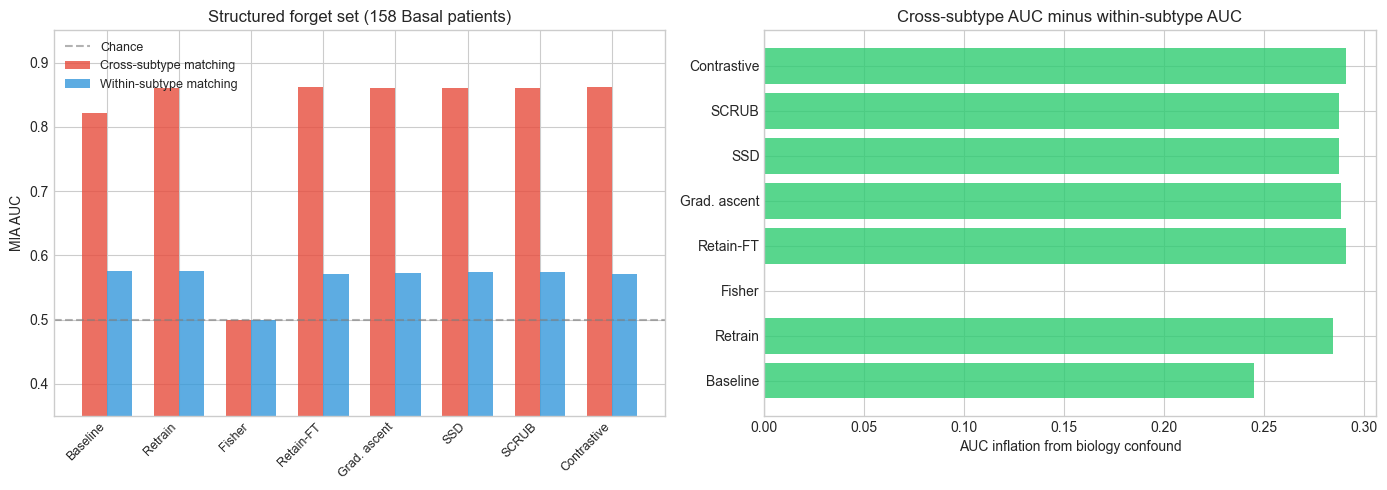

In [4]:
methods = ['baseline', 'retrain', 'Fisher', 'Retain-FT', 'Grad. ascent', 'SSD', 'SCRUB', 'Contrastive']
labels = [m.capitalize() if m in ('baseline','retrain') else m for m in methods]

cs_vals = [cross_sub[m] for m in methods]
ws_vals = [structured_results[m]['auc'] for m in methods]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: side-by-side bars
x = np.arange(len(methods))
w = 0.35
bars1 = axes[0].bar(x - w/2, cs_vals, w, label='Cross-subtype matching', color='#e74c3c', alpha=0.8)
bars2 = axes[0].bar(x + w/2, ws_vals, w, label='Within-subtype matching', color='#3498db', alpha=0.8)
axes[0].axhline(0.5, color='gray', ls='--', alpha=0.6, label='Chance')
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels, rotation=45, ha='right', fontsize=9)
axes[0].set_ylabel('MIA AUC')
axes[0].set_ylim(0.35, 0.95)
axes[0].legend(fontsize=9)
axes[0].set_title('Structured forget set (158 Basal patients)')

# Right: the confound magnitude
confound = [cs - ws for cs, ws in zip(cs_vals, ws_vals)]
colors = ['#2ecc71' if c > 0.05 else '#95a5a6' for c in confound]
axes[1].barh(labels, confound, color=colors, alpha=0.8)
axes[1].set_xlabel('AUC inflation from biology confound')
axes[1].set_title('Cross-subtype AUC minus within-subtype AUC')
axes[1].axvline(0, color='gray', ls='-', alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'biology_confound_structured.png', dpi=150, bbox_inches='tight')
plt.show()

In [5]:
# Summary table
rows = []
for m in methods:
    rows.append({
        'Method': m.capitalize() if m in ('baseline','retrain') else m,
        'Cross-sub AUC': cross_sub[m],
        'Within-sub AUC': structured_results[m]['auc'],
        'Δ AUC': cross_sub[m] - structured_results[m]['auc'],
        'Within-sub advantage': structured_results[m]['advantage'],
    })
df = pd.DataFrame(rows).set_index('Method')
df.style.format('{:.3f}').bar(subset=['Δ AUC'], color='#e74c3c', vmin=0, vmax=0.4)

,Cross-sub AUC,Within-sub AUC,Δ AUC,Within-sub advantage
Method,,,,
Baseline,0.821,0.576,0.245,0.153
Retrain,0.860,0.576,0.284,0.151
Fisher,0.500,0.500,0.000,0.000
Retain-FT,0.862,0.571,0.291,0.142
Grad. ascent,0.861,0.573,0.288,0.145
SSD,0.861,0.573,0.288,0.147
SCRUB,0.861,0.574,0.287,0.148
Contrastive,0.862,0.571,0.291,0.142


With within-subtype matching, baseline AUC drops from 0.821 to 0.576. Retrain
drops from 0.860 to 0.576. They are now indistinguishable. The entire cross-subtype
signal (AUC 0.821) was detecting Basal identity, not memorization.

## Part 2: Patient-level forget sets (5, 10, 20 Basal patients)

In [6]:
patient_results = {}

for n_patients in [5, 10, 20]:
    with open(f'../outputs/tcga_brca/split_patient_{n_patients}.json') as f:
        psplit = json.load(f)
    forget_idx = psplit['forget_indices']
    patient_results[n_patients] = {
        'baseline': eval_within_subtype(baseline_model, forget_idx),
        'retrain': eval_within_subtype(retrain_model, forget_idx),
    }
    # Load patient-level unlearning checkpoints if available
    for method, dirname in [('Retain-FT', 'retain_ft'), ('Grad. ascent', 'ga')]:
        p = Path(f'../outputs/tcga_brca/patient_unlearning/{dirname}_n{n_patients}/best_model.pt')
        if p.exists():
            patient_results[n_patients][method] = eval_within_subtype(load_model(p), forget_idx)

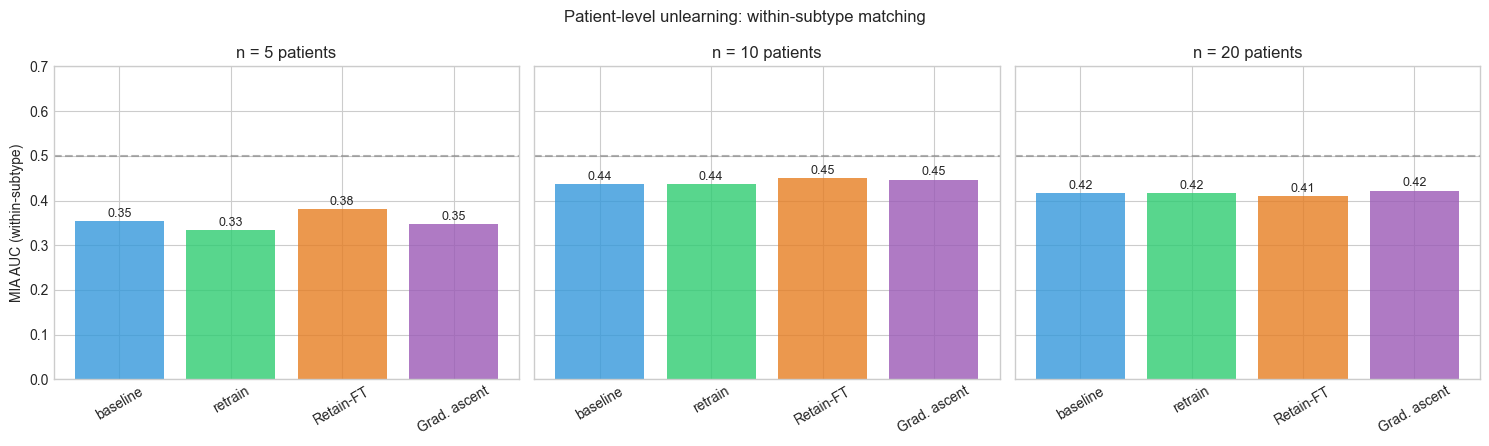

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5), sharey=True)

for i, n in enumerate([5, 10, 20]):
    res = patient_results[n]
    names = list(res.keys())
    aucs = [res[m]['auc'] for m in names]

    bars = axes[i].bar(names, aucs, color=['#3498db', '#2ecc71', '#e67e22', '#9b59b6'][:len(names)], alpha=0.8)
    axes[i].axhline(0.5, color='gray', ls='--', alpha=0.6)
    axes[i].set_title(f'n = {n} patients')
    axes[i].set_ylim(0.0, 0.7)
    if i == 0:
        axes[i].set_ylabel('MIA AUC (within-subtype)')
    axes[i].tick_params(axis='x', rotation=30)

    for bar, auc in zip(bars, aucs):
        axes[i].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,
                     f'{auc:.2f}', ha='center', fontsize=9)

plt.suptitle('Patient-level unlearning: within-subtype matching', fontsize=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'patient_level_within_subtype.png', dpi=150, bbox_inches='tight')
plt.show()

In [8]:
# Patient-level summary table
rows = []
for n in [5, 10, 20]:
    for method, res in patient_results[n].items():
        rows.append({'n': n, 'Method': method, 'AUC': res['auc'], 'Advantage': res['advantage']})
pd.DataFrame(rows).pivot_table(index='Method', columns='n', values='AUC').style.format('{:.3f}')

n,5,10,20
Method,,,
Grad. ascent,0.347,0.447,0.422
Retain-FT,0.380,0.450,0.410
baseline,0.353,0.437,0.417
retrain,0.333,0.437,0.417


Baseline and retrain AUCs are indistinguishable at every patient-level size.
There is no detectable patient-level memorization on TCGA-BRCA with proper matching.

## Part 3: Confound magnitude across datasets

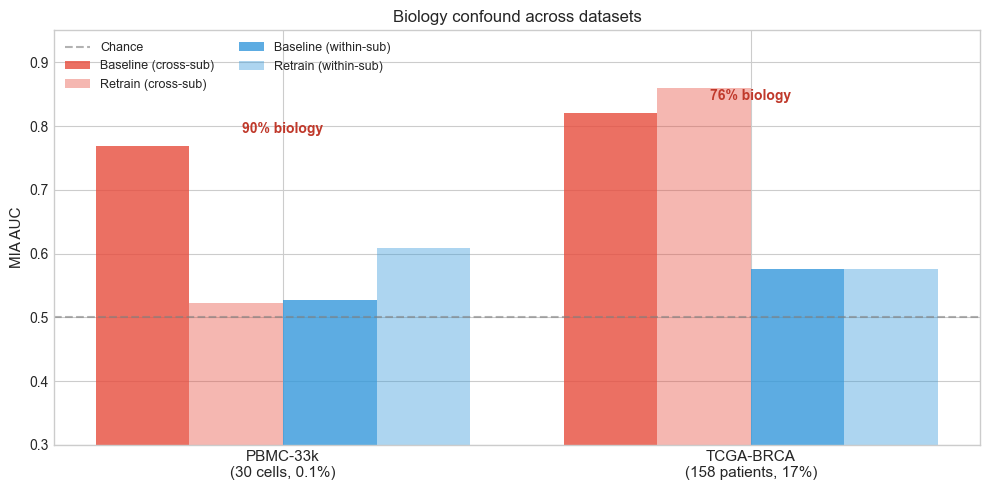

In [9]:
# PBMC data from NB19
pbmc_matched_val = json.load(open('../outputs/matched_negative_validation.json'))
pbmc_cs_baseline = 0.769
pbmc_ws_baseline = pbmc_matched_val['within_cluster']['results']['Baseline']['mean_auc']
pbmc_cs_retrain = 0.523
pbmc_ws_retrain = pbmc_matched_val['within_cluster']['results']['Retrain']['mean_auc']

tcga_cs_baseline = 0.821
tcga_ws_baseline = structured_results['baseline']['auc']
tcga_cs_retrain = 0.860
tcga_ws_retrain = structured_results['retrain']['auc']

fig, ax = plt.subplots(figsize=(10, 5))

datasets = ['PBMC-33k\n(30 cells, 0.1%)', 'TCGA-BRCA\n(158 patients, 17%)']
x = np.arange(len(datasets))
w = 0.2

ax.bar(x - 1.5*w, [pbmc_cs_baseline, tcga_cs_baseline], w,
       label='Baseline (cross-sub)', color='#e74c3c', alpha=0.8)
ax.bar(x - 0.5*w, [pbmc_cs_retrain, tcga_cs_retrain], w,
       label='Retrain (cross-sub)', color='#e74c3c', alpha=0.4)
ax.bar(x + 0.5*w, [pbmc_ws_baseline, tcga_ws_baseline], w,
       label='Baseline (within-sub)', color='#3498db', alpha=0.8)
ax.bar(x + 1.5*w, [pbmc_ws_retrain, tcga_ws_retrain], w,
       label='Retrain (within-sub)', color='#3498db', alpha=0.4)

ax.axhline(0.5, color='gray', ls='--', alpha=0.6, label='Chance')
ax.set_xticks(x)
ax.set_xticklabels(datasets, fontsize=11)
ax.set_ylabel('MIA AUC', fontsize=11)
ax.set_ylim(0.3, 0.95)
ax.legend(ncol=2, fontsize=9, loc='upper left')
ax.set_title('Biology confound across datasets', fontsize=12)

# Annotate confound fractions
for i, (cs_b, ws_b) in enumerate([(pbmc_cs_baseline, pbmc_ws_baseline),
                                   (tcga_cs_baseline, tcga_ws_baseline)]):
    frac = (cs_b - ws_b) / (cs_b - 0.5) if cs_b > 0.5 else 0
    ax.annotate(f'{frac:.0%} biology', xy=(i, max(cs_b, ws_b) + 0.02),
                ha='center', fontsize=10, fontweight='bold', color='#c0392b')

plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confound_across_datasets.png', dpi=150, bbox_inches='tight')
plt.show()

Cross-subtype matching inflates the MIA signal by detecting subtype identity.
With within-subtype matching, baseline and retrain converge to the same AUC on
both datasets. On PBMC, approximately 90% of the cross-subtype signal is biology.
On TCGA-BRCA, approximately 76%.

## Save results

In [10]:
all_results = {
    'dataset': 'TCGA-BRCA',
    'matching': 'within_subtype',
    'matched_subtype': 'Basal',
    'n_matched': len(unseen_basal),
    'structured': structured_results,
    'patient_level': {str(k): v for k, v in patient_results.items()},
    'comparison_cross_subtype': {
        'baseline_auc': 0.821,
        'retrain_auc': 0.860,
    }
}
with open(OUTPUT_DIR / 'within_subtype_results.json', 'w') as f:
    json.dump(all_results, f, indent=2)

## Summary

| Output | Path |
|--------|------|
| Confound comparison figure | `outputs/tcga_brca/within_subtype_eval/biology_confound_structured.png` |
| Patient-level figure | `outputs/tcga_brca/within_subtype_eval/patient_level_within_subtype.png` |
| Cross-dataset confound figure | `outputs/tcga_brca/within_subtype_eval/confound_across_datasets.png` |
| Results JSON | `outputs/tcga_brca/within_subtype_eval/within_subtype_results.json` |